In [1]:
import pandas as pd 
import numpy
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors  import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,ConfusionMatrixDisplay,precision_score,recall_score,f1_score
from imblearn.over_sampling import SMOTE

In [2]:
import sys
sys.executable

'c:\\Users\\hafee\\AppData\\Local\\Programs\\Python\\Python310\\python.exe'

In [3]:
df = pd.read_csv(r"C:\Users\hafee\OneDrive\Desktop\Desktop\Ham or spam Mail Detection\spam.csv",encoding='ISO-8859-1')
df.head()


,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.drop(['Unnamed: 2','Unnamed: 3','Unnamed: 4'],axis=1,inplace=True)

In [5]:
print(df.isna().sum())

v1    0
v2    0
dtype: int64


In [6]:
x=df['v2']
y=df['v1']

v1
ham     4825
spam     747
Name: count, dtype: int64


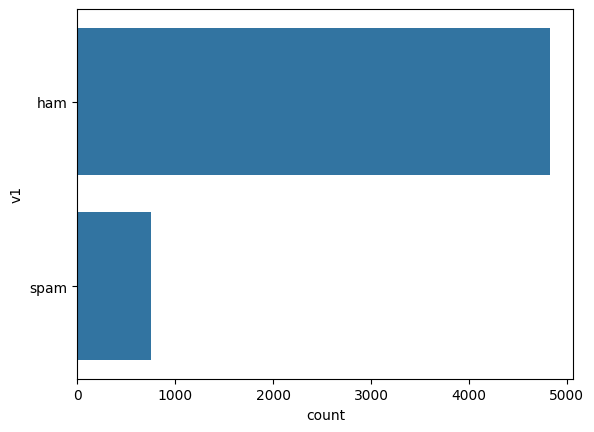

In [7]:
sns.countplot(y)
print(df.value_counts(y))


In [8]:
y = y.map({'ham':0,'spam':1})
y

0       0
1       0
2       1
3       0
4       0
       ..
5567    1
5568    0
5569    0
5570    0
5571    0
Name: v1, Length: 5572, dtype: int64

In [9]:
x = x.str.replace('[^a-z A-Z 0-9]',' ',regex=True)

In [10]:
x

0       Go until jurong point  crazy   Available only ...
1                           Ok lar    Joking wif u oni   
2       Free entry in 2 a wkly comp to win FA Cup fina...
3       U dun say so early hor    U c already then say   
4       Nah I don t think he goes to usf  he lives aro...
                              ...                        
5567    This is the 2nd time we have tried 2 contact u...
5568                Will    b going to esplanade fr home 
5569    Pity    was in mood for that  So   any other s...
5570    The guy did some bitching but I acted like i d...
5571                           Rofl  Its true to its name
Name: v2, Length: 5572, dtype: object

In [11]:
nltk.download('punkt_tab')
nltk.download('wordnet')

wn = WordNetLemmatizer()
x = x.apply(lambda text: ' '.join(
    [wn.lemmatize(word.lower(), pos='v') for word in word_tokenize(text)]
))
 

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\hafee\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hafee\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [12]:
nltk.download('stopwords')
sp = stopwords.words('english')
x = x.apply(lambda x: ' '.join(
    [i for i in x.split() if i not in sp]
))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hafee\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [13]:
tfidf = TfidfVectorizer()
x = tfidf.fit_transform(x)
print(x)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 46900 stored elements and shape (5572, 7522)>
  Coords	Values
  (0, 3155)	0.13443502877007854
  (0, 3849)	0.3530727615305335
  (0, 5228)	0.24108554631217946
  (0, 2108)	0.27343054938334227
  (0, 1250)	0.2640869109948604
  (0, 1639)	0.298277295703572
  (0, 3232)	0.1950375880045688
  (0, 7370)	0.2388262700717711
  (0, 3957)	0.298277295703572
  (0, 1637)	0.3370461151713735
  (0, 1880)	0.298277295703572
  (0, 3116)	0.12439720751056202
  (0, 1044)	0.3530727615305335
  (0, 7189)	0.19727553887440005
  (1, 4862)	0.2811632882742994
  (1, 3990)	0.4218684931830353
  (1, 3816)	0.47451057922863127
  (1, 7291)	0.4459451111953121
  (1, 4889)	0.5647537939557097
  (2, 2982)	0.11601151784896217
  (2, 2647)	0.3620653949245797
  (2, 7336)	0.1916429305165397
  (2, 1983)	0.1956073274262506
  (2, 7302)	0.1252127937860932
  (2, 2772)	0.4724600479085474
  :	:
  (5567, 165)	0.33673865829430394
  (5567, 4789)	0.33673865829430394
  (5568, 3155)	0.28337

In [14]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)


In [15]:
smote = SMOTE()
x_train_sm,y_train_sm = smote.fit_resample(x_train.toarray(),y_train)

In [16]:
models = [RandomForestClassifier(),
        KNeighborsClassifier(),
        SVC()]
for model in models:
    model.fit(x_train_sm,y_train_sm)


In [19]:

X_train = x_train_sm
X_test = x_test.toarray()

train_accuracy = []
test_accuracy = []
precision_scores = []
recall_scores = []
f1_scores = []

for model in models:
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy.append(metrics.accuracy_score(y_train_sm, y_train_pred))
    test_accuracy.append(metrics.accuracy_score(y_test, y_test_pred))

    # Other metrics
    precision_scores.append(metrics.precision_score(y_test, y_test_pred, average='weighted', zero_division=0))
    recall_scores.append(metrics.recall_score(y_test, y_test_pred, average='weighted', zero_division=0))
    f1_scores.append(metrics.f1_score(y_test, y_test_pred, average='weighted', zero_division=0))



In [21]:
data = {'train_accuracy':train_accuracy,
        'test_accuracy':test_accuracy,
        'precision':precision_scores,
        'recall':recall_scores,
        'f1_score':f1_scores,}
       
model_name = ["RandomForestClassifier" , "KNeighborsClassifier","SVC"]
result = pd.DataFrame(data, index=model_name)
result

,train_accuracy,test_accuracy,precision,recall,f1_score
RandomForestClassifier,1.000000,0.982063,0.982427,0.982063,0.981514
KNeighborsClassifier,0.998705,0.954260,0.955992,0.954260,0.950362
SVC,1.000000,0.973991,0.974478,0.973991,0.972884


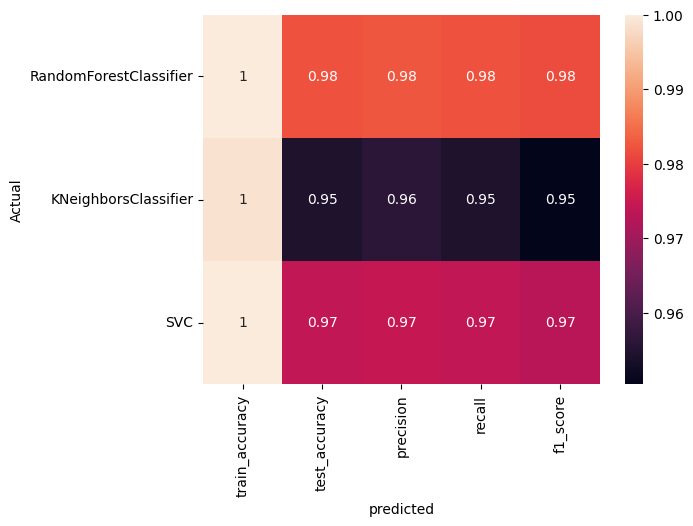

In [22]:
sns.heatmap(result,annot=True)
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
best_index = result['recall'].idxmax()
best_model = models[model_name.index(best_index)]

print("Best Model based on Recall:", best_index)

Best Model based on Recall: RandomForestClassifier


In [27]:
import joblib

joblib.dump(best_model, "model.jbl")
joblib.dump(tfidf, "tfidf_vectorizer.jbl")

['tfidf_vectorizer.jbl']